# 24. Ранжирование поисковой выдачи: 5000 запросов, ~150 000 пар «запрос — документ»

| | |
|---|---|
| **Уровень** | 4 из 4 — большие данные и сложные задачи (`4_large`) |
| **Скрипт-источник** | [`24_learning_to_rank.py`](../24_learning_to_rank.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 7 с |

**Цель.** Обучить бустинг упорядочивать документы внутри запроса, а не предсказывать числа.

### Чему вы научитесь

- Данные с группами (`qid`)
- Разбиение по запросам
- Метрика NDCG@k
- Три подхода: поточечный (регрессия оценки), попарный (`rank:pairwise`) и списочный (LambdaMART: `rank:ndcg`, `lambdarank`)
- `XGBRanker` и `LGBMRanker`
- Почему ранжирующая модель выдаёт не вероятности, а баллы

### Данные

`_data.make_search` — 5000 запросов по 10–50 документов, 12 признаков (сходство текста, популярность, свежесть …), оценка релевантности 0–4 (3% документов — «отлично»).

### План

1. **Этап 1.** Данные
2. **Этап 2.** Разбиение по запросам: документы одного запроса не должны попасть в разные части
3. **Этап 3.** NDCG@10: насколько верх выдачи близок к идеальному порядку (1 — идеально)
4. **Этап 4.** Три подхода на одних признаках (ранняя остановка по валидации)
5. **Этап 5.** Один запрос из теста: как модель переставила документы
6. **Этап 6.** Выводы

> Ноутбук собран из `examples/4_large/24_learning_to_rank.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example
from _data import make_search

ex = Example(EXAMPLES / "4_large/24_learning_to_rank.py", title="24. Ранжирование поисковой выдачи",
             goal="обучить бустинг упорядочивать документы внутри запроса")

import lightgbm as lgb
import numpy as np
import xgboost as xgb
from sklearn.metrics import ndcg_score

## Этап 1. Данные

In [2]:
X, rel, qid = make_search(ex.size(5000, 1500))
ex.describe(X, rel, names=[f"x{j}" for j in range(12)], target="релевантность", task="classification",
            source="examples/_data.py → make_search (строки упорядочены по запросу)")
sizes = np.bincount(qid)
print(f"   запросов {len(sizes)}; документов на запрос: от {sizes.min()} до {sizes.max()}, в среднем {sizes.mean():.1f}")

   Источник: examples/_data.py → make_search (строки упорядочены по запросу)
   Объектов: 149 385   признаков: 12   память: 13.68 МБ
   Типы признаков: float64 × 12
   Пропусков нет
   Цель «релевантность»: класс 0 — 75956 (50.8%), класс 1 — 35407 (23.7%), класс 2 — 21379 (14.3%), класс 3 — 9750 (6.5%), класс 4 — 6893 (4.6%)
   Первые строки:


,x0,x1,x2,x3,x4,x5,...,x7,x8,x9,x10,x11,[релевантность]
0,-0.132105,0.640423,0.104900,-0.535669,0.361595,1.304000,...,-0.703735,-1.265421,-0.623274,0.041326,-2.325031,2
1,-0.218792,-1.245911,-0.732267,-0.544259,-0.316300,0.411631,...,-0.128535,1.366463,-0.665195,0.351510,0.903470,0
2,0.094012,-0.743499,-0.921725,-0.457726,0.220195,-1.009618,...,-0.159225,0.540846,0.214659,0.355373,-0.653829,0


   запросов 5000; документов на запрос: от 10 до 50, в среднем 29.9


## Этап 2. Разбиение по запросам: документы одного запроса не должны попасть в разные части

In [3]:
queries = np.random.default_rng(0).permutation(len(sizes))
nq = len(sizes)
part = np.empty(nq, int)
part[queries[: int(0.7 * nq)]], part[queries[int(0.7 * nq): int(0.85 * nq)]], part[queries[int(0.85 * nq):]] = 0, 1, 2
row_part = part[qid]
sel = {k: np.flatnonzero(row_part == i) for i, k in enumerate(("tr", "va", "te"))}   # строки сохраняют порядок qid
group = {k: np.bincount(qid[idx])[np.unique(qid[idx])] for k, idx in sel.items()}
print("   запросов: " + ", ".join(f"{k} {len(v)}" for k, v in group.items()))
ex.note("Ранжировщикам нужны размеры групп в порядке следования строк: строки одного запроса идут подряд.")

   запросов: tr 3500, va 750, te 750


> ▸ **Вывод.** Ранжировщикам нужны размеры групп в порядке следования строк: строки одного запроса идут подряд.

## Этап 3. NDCG@10: насколько верх выдачи близок к идеальному порядку (1 — идеально)

In [4]:
def ndcg_at(scores, idx, k=10):
    vals = []
    for q in np.unique(qid[idx]):
        rows = idx[qid[idx] == q]
        if rel[rows].max() == 0:
            continue
        vals.append(ndcg_score([rel[rows]], [scores[np.searchsorted(idx, rows)]], k=k))
    return float(np.mean(vals))


te_idx = sel["te"]
rng = np.random.default_rng(1)
print(f"   случайный порядок {ndcg_at(rng.random(len(te_idx)), te_idx):.4f}; "
      f"по одному лучшему признаку x0 {ndcg_at(X[te_idx, 0], te_idx):.4f}")

   случайный порядок 0.3725; по одному лучшему признаку x0 0.7340


## Этап 4. Три подхода на одних признаках (ранняя остановка по валидации)

   поточечный: регрессия оценки         NDCG@10 0.9125


   попарный: rank:pairwise              NDCG@10 0.9114


   списочный: rank:ndcg (LambdaMART)    NDCG@10 0.9113


   списочный: LightGBM lambdarank       NDCG@10 0.9119


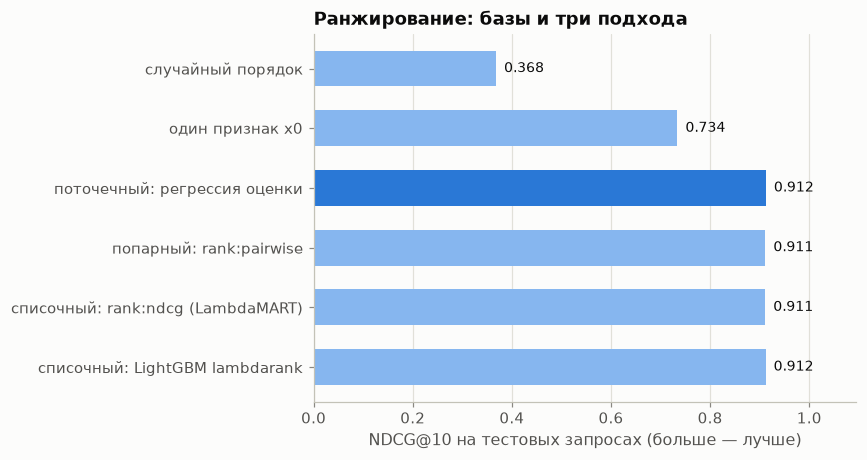

In [5]:
common = dict(n_estimators=2000, learning_rate=0.05, max_depth=6, tree_method="hist", early_stopping_rounds=50)
results = {}
pointwise = xgb.XGBRegressor(**common).fit(X[sel["tr"]], rel[sel["tr"]], eval_set=[(X[sel["va"]], rel[sel["va"]])], verbose=False)
results["поточечный: регрессия оценки"] = pointwise.predict(X[te_idx])
for obj, name in (("rank:pairwise", "попарный: rank:pairwise"), ("rank:ndcg", "списочный: rank:ndcg (LambdaMART)")):
    rk = xgb.XGBRanker(objective=obj, eval_metric="ndcg@10", **common)
    rk.fit(X[sel["tr"]], rel[sel["tr"]], qid=qid[sel["tr"]], eval_set=[(X[sel["va"]], rel[sel["va"]])],
           eval_qid=[qid[sel["va"]]], verbose=False)
    results[name] = rk.predict(X[te_idx])
lr = lgb.LGBMRanker(n_estimators=2000, learning_rate=0.05, num_leaves=31, verbose=-1, random_state=0)
lr.fit(X[sel["tr"]], rel[sel["tr"]], group=group["tr"], eval_X=(X[sel["va"]],), eval_y=(rel[sel["va"]],),
       eval_group=[group["va"]], eval_at=[10], callbacks=[lgb.early_stopping(50, verbose=False)])
results["списочный: LightGBM lambdarank"] = lr.predict(X[te_idx])
ndcg = {"случайный порядок": ndcg_at(rng.random(len(te_idx)), te_idx), "один признак x0": ndcg_at(X[te_idx, 0], te_idx)}
for name, s in results.items():
    ndcg[name] = ndcg_at(s, te_idx)
    print(f"   {name:36s} NDCG@10 {ndcg[name]:.4f}")
ex.barh(ndcg, best=max(ndcg, key=ndcg.get), name="24_ndcg", fmt="{:.3f}",
        xlabel="NDCG@10 на тестовых запросах (больше — лучше)", title="Ранжирование: базы и три подхода")

## Этап 5. Один запрос из теста: как модель переставила документы

In [6]:
q = np.unique(qid[te_idx])[0]
rows = np.flatnonzero(qid[te_idx] == q)
s = results["списочный: LightGBM lambdarank"][rows]
order = np.argsort(-s)
print(f"   запрос {q}, документов {len(rows)}")
print(f"   исходный порядок, первые 10 оценок:   {rel[te_idx][rows][:10].tolist()}")
print(f"   после ранжирования, первые 10 оценок: {rel[te_idx][rows][order][:10].tolist()}")
print(f"   баллы модели у первых трёх: {np.round(s[order][:3], 2).tolist()} — это не вероятности, важен только порядок")

   запрос 3, документов 48
   исходный порядок, первые 10 оценок:   [2, 0, 0, 0, 0, 0, 1, 1, 0, 0]
   после ранжирования, первые 10 оценок: [4, 4, 3, 3, 2, 2, 2, 1, 2, 3]
   баллы модели у первых трёх: [3.95, 2.75, 1.99] — это не вероятности, важен только порядок


## Этап 6. Выводы

In [7]:
ex.note("""Любой подход многократно лучше случайного порядка и лучше одного признака.
На этих данных все четыре подхода совпали с точностью до 0.001: признаки хорошо объясняют оценку, и точная
регрессия оценки сама даёт хороший порядок. Списочные цели выигрывают, когда шкалы оценок в запросах разные
или важны только первые позиции, — сравнивайте на своих данных.
Главное — корректные группы и разбиение по запросам.""")
ex.done()

> ▸ **Вывод.** Любой подход многократно лучше случайного порядка и лучше одного признака. На этих данных все четыре подхода совпали с точностью до 0.001: признаки хорошо объясняют оценку, и точная регрессия оценки сама даёт хороший порядок. Списочные цели выигрывают, когда шкалы оценок в запросах разные или важны только первые позиции, — сравнивайте на своих данных. Главное — корректные группы и разбиение по запросам.

Готово за 5.8 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Считайте NDCG@3 вместо NDCG@10 — растёт ли разрыв между подходами?
2. Для поточечной модели вычтите из оценок среднее по запросу — изменится ли качество?
3. Поменяйте `lambdarank_truncation_level` у LightGBM и сравните NDCG.

## Что дальше

- **Теория в курсе:** [13.1 «Ранжирование: LambdaMART»](../../../lessons/lesson_13_1/README.md).
- **Предыдущий пример:** [23. Прогноз продаж: 50 магазинов × 2 года, признаки из прошлого и разбиение по времени](23_time_series_forecasting.ipynb)
- **Следующий пример:** [25. Страхование: частота (Пуассон), ущерб (Твиди), экспозиция — 200 000 полисов](25_insurance_poisson_tweedie.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)